In [1]:
# -----------------------------
# Import libraries
# -----------------------------

# Core
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


In [2]:
# -----------------------------
# Import pollen data
# -----------------------------

all_pollen_clean = pd.read_csv("all_pollen_clean_tax.csv", encoding="latin1", low_memory=False)


C:\Users\rah10\AppData\Local\Temp\ipykernel_26112\3470757522.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  presence[meta_cols] = all_pollen_clean[meta_cols]


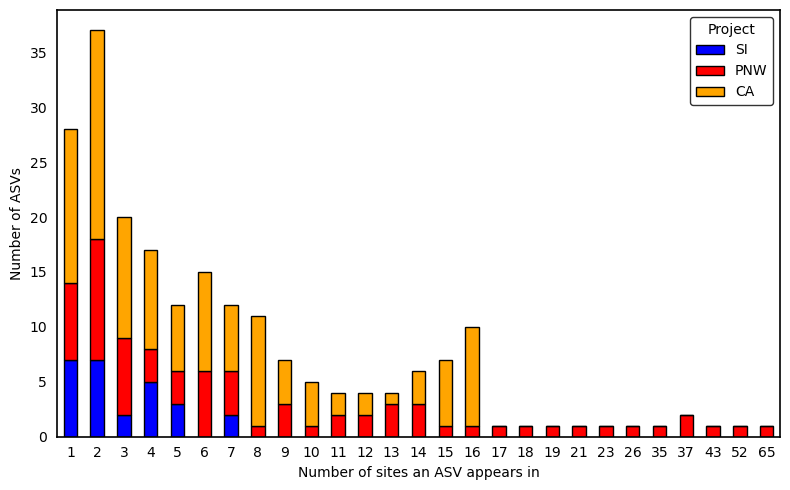

In [3]:

# ------------------------------
# Plot distribution across sites
# ------------------------------


# Separate metadata and ASV columns
meta_cols = ["UniqueID", "Site", "Project"]
asv_cols = [c for c in all_pollen_clean.columns if c not in meta_cols]

# Convert relative abundance to presence/absence
presence = (all_pollen_clean[asv_cols] > 0).astype(int)

# Add metadata back
presence[meta_cols] = all_pollen_clean[meta_cols]

# Count in how many sites each ASV occurs per Project 
presence_long = presence.melt(
    id_vars=meta_cols, value_vars=asv_cols,
    var_name="ASV", value_name="Presence"
)

# Keep only present (1) entries
presence_long = presence_long[presence_long["Presence"] == 1]

# Count sites per ASV per project
asv_site_counts = (
    presence_long.groupby(["Project", "ASV"])["Site"]
    .nunique()
    .reset_index()
    .rename(columns={"Site": "NumSites"})
)

# Histogram table
hist_table = asv_site_counts.groupby(["NumSites", "Project"]).size().unstack(fill_value=0)

# Color map for projects
color_map = {
    "SI": "blue",
    "PNW": "red",
    "CA": "orange"
}

# Reorder columns to ensure colors match correct order
ordered_projects = [p for p in ["SI", "PNW", "CA"] if p in hist_table.columns]

# Plot
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")

hist_table[ordered_projects].plot(
    kind="bar",
    stacked=True,
    edgecolor='black',
    color=[color_map[p] for p in ordered_projects],
    ax=ax
)

ax.set_xlabel("Number of sites an ASV appears in", color='black')
ax.set_ylabel("Number of ASVs", color='black')
#ax.set_title("Distribution of Clustered ASV Occurrence Across Sites by Project", color='black')

plt.xticks(rotation=0, color='black')
plt.yticks(color='black')
plt.legend(title="Project")
plt.tight_layout()

# Legend with white background + black text
leg = plt.legend(title="Project")
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('black')

# Set legend text color to black
for text in leg.get_texts():
    text.set_color("black")

# Set legend title color to black
leg.get_title().set_color("black")


# Make axes border lines black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)   # optional: makes the lines a little thicker

plt.show()


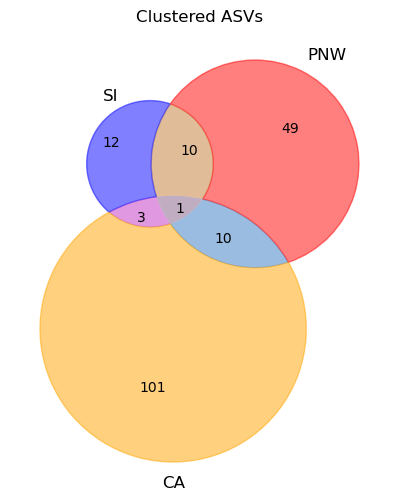

In [4]:
# --------------------------------
# Plot overlap of ASVs among sites
# --------------------------------

# Get unique ASVs per project
projects = presence_long["Project"].unique()

if len(projects) != 3:
    raise ValueError("There must be exactly 3 projects for a 3-set Venn diagram")

# Convert project names to sets
sets = {
    proj: set(presence_long.loc[presence_long["Project"] == proj, "ASV"])
    for proj in projects
}

# Define colors for each project
color_map = {
    "SI": "blue",
    "PNW": "red",
    "CA": "orange"
}

# Ensure projects appear in this fixed order:
ordered_projects = ["SI", "PNW", "CA"]
set_list = [sets[p] for p in ordered_projects]
color_list = [color_map[p] for p in ordered_projects]

# Plot
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

v = venn3(subsets=set_list, set_labels=ordered_projects, ax=ax)

# Assign circle colors
for subset, color in zip(["10", "01", "11"], color_list):
    # venn3 subset areas for the main circles: '100', '010', '001'
    # color entire circles by setting their patches directly
    pass

# Proper way: set patch colors by region
# 100 = first set, 010 = second set, 001 = third set
region_map = {
    "100": color_map["SI"],
    "010": color_map["PNW"],
    "001": color_map["CA"]
}

for region, color in region_map.items():
    if v.get_patch_by_id(region) is not None:
        v.get_patch_by_id(region).set_color(color)
        v.get_patch_by_id(region).set_alpha(0.5)

plt.title("Clustered ASVs", color="black")
plt.show()
